In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
np.random.seed(2137)
torch.manual_seed(2137)


In [2]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")
target = "SalePrice"

cat_cols = (
    train_df.drop(columns=[target])
    .select_dtypes(include=["object", "string"])
    .columns.tolist()
)
num_cols = (
    train_df.drop(columns=[target])
    .select_dtypes(exclude=["object", "string"])
    .columns.tolist()
)

In [3]:
bins = [-float("inf"), 100000, 350000, float("inf")]
labels = [0, 1, 2]
train_df[target] = pd.cut(train_df[target], bins=bins, labels=labels).astype(int)

In [4]:
train_encoded = pd.get_dummies(train_df[cat_cols], prefix=cat_cols)
test_encoded = pd.get_dummies(test_df[cat_cols], prefix=cat_cols)

test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

train_df = pd.concat([train_df[num_cols], train_encoded, train_df[target]], axis=1)
test_df = pd.concat([test_df[num_cols], test_encoded], axis=1)

cat_cols = train_encoded.columns.tolist()

In [5]:
train_df.head()

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),...,TimeToSubway_no_bus_stop_nearby,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice
0,2006,814,3,111.0,184.0,3.0,0.0,5,6.0,9.0,...,False,False,False,False,False,True,False,False,False,1
1,1985,587,8,80.0,76.0,2.0,2.0,3,12.0,4.0,...,False,False,False,False,True,False,False,False,False,0
2,1985,587,6,80.0,76.0,2.0,2.0,3,12.0,4.0,...,False,False,False,False,True,False,False,False,False,0
3,2006,2056,8,249.0,536.0,5.0,11.0,5,3.0,7.0,...,False,False,False,False,False,False,False,True,False,2
4,1992,644,2,142.0,79.0,4.0,8.0,3,9.0,14.0,...,False,False,False,False,False,False,True,False,False,0


In [6]:
class MultiClassClassifier(nn.Module):
    def __init__(self, input, output):
        super(MultiClassClassifier, self).__init__()

        self.fully_connected1 = nn.Linear(input, 100)
        self.batch_norm1 = nn.BatchNorm1d(100)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.5)
        self.fully_connected2 = nn.Linear(100, 300)
        self.batch_norm2 = nn.BatchNorm1d(300)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.5)
        self.fully_connected3 = nn.Linear(300, 100)
        self.batch_norm3 = nn.BatchNorm1d(100)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(p=0.5)
        self.fully_connected4 = nn.Linear(100, output)

    def forward(self, X_categorical, X_non_categorical):
        x = torch.cat([X_categorical, X_non_categorical], dim=1)

        x = self.fully_connected1(x)
        x = self.batch_norm1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fully_connected2(x)
        x = self.batch_norm2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fully_connected3(x)
        x = self.batch_norm3(x)
        x = self.relu3(x)
        x = self.dropout3(x)

        x = self.fully_connected4(x)
        return x


In [7]:
X_cat = torch.tensor(train_df[cat_cols].values, dtype=torch.float32)
X_num = torch.tensor(train_df[num_cols].values, dtype=torch.float32)
y = torch.tensor(train_df[target].values, dtype=torch.int64)

X_cat_test = torch.tensor(test_df[cat_cols].values, dtype=torch.float32)
X_num_test = torch.tensor(test_df[num_cols].values, dtype=torch.float32)

X_cat_train, X_cat_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_cat, X_num, y, test_size=0.15, random_state=42
)

train_dataset = TensorDataset(X_cat_train, X_num_train, y_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [8]:
from sklearn.preprocessing import QuantileTransformer

X_cat = train_df[cat_cols]
X_num = train_df[num_cols]
y = train_df[target]

X_cat_test = test_df[cat_cols]
X_num_test = test_df[num_cols]

X_cat_train, X_cat_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_cat, X_num, y, test_size=0.15, random_state=42
)

scaler = StandardScaler()
X_num_train[num_cols] = scaler.fit_transform(X_num_train)
X_num_val[num_cols] = scaler.transform(X_num_val)
X_num_test[num_cols] = scaler.transform(X_num_test)
transformer = QuantileTransformer()
X_num_train[num_cols] = transformer.fit_transform(X_num_train)
X_num_val[num_cols] = transformer.transform(X_num_val)
X_num_test[num_cols] = transformer.transform(X_num_test)

X_cat_train = torch.tensor(X_cat_train.values, dtype=torch.int64)
X_num_train = torch.tensor(X_num_train.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.int64)


X_cat_val = torch.tensor(X_cat_val.values, dtype=torch.int64)
X_num_val = torch.tensor(X_num_val.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.int64)

X_cat_test = torch.tensor(X_cat_test.values, dtype=torch.int64)
X_num_test = torch.tensor(X_num_test.values, dtype=torch.float32)


train_dataset = TensorDataset(X_cat_train, X_num_train, y_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [9]:
def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct = (pred_targets == targets)[targets == i].sum()
        accuracies.append(class_correct / (targets == i).sum())
    return np.mean(accuracies)

def evaluate(model, X_cat_val, X_num_val, y_val):
    with torch.no_grad():
        outputs = model(X_cat_val, X_num_val)
        _, predicted = torch.max(outputs, 1)
        accuracy = calc_accuracy(predicted.numpy(), y_val.numpy())
    return accuracy

In [10]:
input_size = len(cat_cols) + len(num_cols)
output_size = len(train_df[target].unique())

class_weights = 1 / train_df[target].value_counts().sort_index()
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)


model = MultiClassClassifier(input_size, output_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

model.train()

losses = []
val_acc = []
train_acc = []

for epoch in range(50):
    epoch_loss = 0.0
    for cat_b, num_b, y_b in train_loader:
        optimizer.zero_grad()
        outputs = model(cat_b, num_b)
        loss = criterion(outputs, y_b)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    losses.append(avg_loss)

    if (epoch + 1) % 1 == 0:
        model.eval()
        val_accuracy = evaluate(model, X_cat_val, X_num_val, y_val)
        train_accuracy = evaluate(model, X_cat_train, X_num_train, y_train)
        print(f"Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        val_acc.append(val_accuracy)
        train_acc.append(train_accuracy)

        model.train()

Epoch 1, Loss: 0.7983
Training Accuracy: 0.7293
Validation Accuracy: 0.7366
Epoch 2, Loss: 0.5738
Training Accuracy: 0.8154
Validation Accuracy: 0.8146
Epoch 3, Loss: 0.4824
Training Accuracy: 0.8546
Validation Accuracy: 0.8552
Epoch 4, Loss: 0.4614
Training Accuracy: 0.8574
Validation Accuracy: 0.8491
Epoch 5, Loss: 0.4356
Training Accuracy: 0.8776
Validation Accuracy: 0.8728
Epoch 6, Loss: 0.4087
Training Accuracy: 0.8776
Validation Accuracy: 0.8714
Epoch 7, Loss: 0.4116
Training Accuracy: 0.8772
Validation Accuracy: 0.8721
Epoch 8, Loss: 0.3837
Training Accuracy: 0.8837
Validation Accuracy: 0.8779
Epoch 9, Loss: 0.3818
Training Accuracy: 0.8856
Validation Accuracy: 0.8825
Epoch 10, Loss: 0.3849
Training Accuracy: 0.8858
Validation Accuracy: 0.8794
Epoch 11, Loss: 0.3787
Training Accuracy: 0.8867
Validation Accuracy: 0.8832
Epoch 12, Loss: 0.3577
Training Accuracy: 0.8865
Validation Accuracy: 0.8809
Epoch 13, Loss: 0.3594
Training Accuracy: 0.8883
Validation Accuracy: 0.8825
Epoch 14

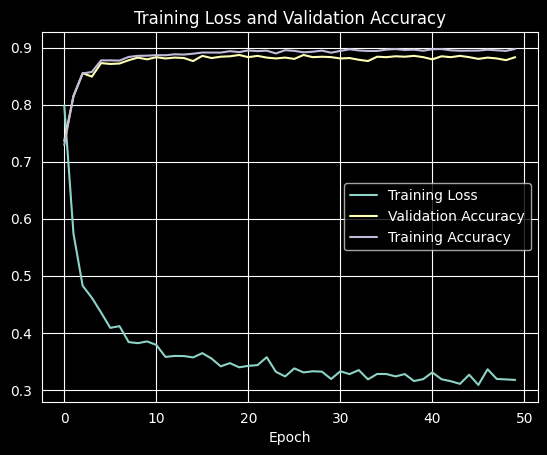

In [11]:
import matplotlib.pyplot as plt

plt.plot(losses, label="Training Loss")
plt.plot(val_acc, label="Validation Accuracy")
plt.plot(train_acc, label="Training Accuracy")
plt.xlabel("Epoch")
plt.title("Training Loss and Validation Accuracy")
plt.legend()
plt.show()

In [12]:
model.eval()
test_outputs = model(X_cat_test, X_num_test)
_, test_predicted = torch.max(test_outputs, 1)

np.savetxt("output.csv", test_predicted.numpy(), delimiter=",", fmt="%d")

In [13]:
model.eval()


def split_summary(split_name, x_cat, x_num, y_true):
    with torch.no_grad():
        logits = model(x_cat, x_num)
        preds = torch.argmax(logits, dim=1)

    class_accuracies = []
    print(f"{split_name} Accuracy per class:")
    for cls in range(output_size):
        cls_mask = y_true == cls
        cls_total = cls_mask.sum().item()

        if cls_total == 0:
            print(f"Class {cls}: N/A (0 samples)")
            continue

        cls_correct = (preds[cls_mask] == y_true[cls_mask]).sum().item()
        cls_accuracy = cls_correct / cls_total
        class_accuracies.append(cls_accuracy)
        print(f"Class {cls}: {cls_accuracy:.2%} ({cls_correct}/{cls_total})")

    overall_accuracy = float(np.mean(class_accuracies)) if class_accuracies else 0.0
    print(f"Overall {split_name} Accuracy (mean per class): {overall_accuracy:.2%}")


split_summary("Train", X_cat_train, X_num_train, y_train)
split_summary("Validation", X_cat_val, X_num_val, y_val)

Train Accuracy per class:
Class 0: 99.57% (465/467)
Class 1: 72.85% (1862/2556)
Class 2: 96.89% (467/482)
Overall Train Accuracy (mean per class): 89.77%
Validation Accuracy per class:
Class 0: 100.00% (95/95)
Class 1: 71.79% (313/436)
Class 2: 93.18% (82/88)
Overall Validation Accuracy (mean per class): 88.32%
